### Directivity Parameters

Comparison of 2 different directivity parameter sets

#### Custom
- Theta
- S

#### Bayless Inputs
- U, T (i.e. Rx, Ry using GC2)
- S = The horizontal length of the rupture travel between the site and the origin
- D = The effective rupture travel width, measured from the hypocentre to the shallowest depth of the rupture plane, up-dip

In [2]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pygmt

# Grow the GPU memory usage as needed
gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices("GPU")
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

import nn_gmm
from qcore import srf, geo

2022-05-02 08:29:54.655033: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-02 08:29:54.765998: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-02 08:29:54.766692: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-02 08:29:54.768249: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

1 Physical GPUs, 1 Logical GPUs


In [21]:
# Config
old_directivity_db = Path("/home/claudy/dev/work/data/nn_gmm/input_data/archive/directivity_s_theta/cybershake_v20p4.db")
directivity_db_ffp = Path("/home/claudy/dev/work/data/nn_gmm/input_data/directivity/cybershake_v20p4.db")
site_params_ffp = Path("/home/claudy/dev/work/data/nn_gmm/input_data/site_params/site_params.csv")
srf_data_dir = Path("/home/claudy/dev/work/data/nn_gmm/input_data/srf_data/cybershake_v20p4")
imdb_ffp = Path("/home/claudy/dev/work/data/nn_gmm/input_data/im_data/cybershake_v20p4_200.h5")
source_params_ffp = Path("/home/claudy/dev/work/data/nn_gmm/input_data/source_rel_params/cybershake_v20p4_200.csv")

# old_directivity_db = Path("/Users/claudy/dev/work/data/nn_gmm/input_data/archive/directivity_s_theta/cybershake_v20p4.db")
# directivity_db_ffp = Path("/Users/claudy/dev/work/data/nn_gmm/input_data/directivity/cybershake_v20p4.db")
# site_params_ffp = Path("/Users/claudy/dev/work/data/nn_gmm/input_data/site_params/site_params.csv")
# srf_data_dir = Path("/Users/claudy/dev/work/data/nn_gmm/input_data/srf_data/cybershake_v20p4")

In [13]:
site_df = pd.read_csv(site_params_ffp, index_col=0)

In [14]:
# List available faults/keys
with pd.HDFStore(directivity_db_ffp) as db:
    print(list(db.keys()))

['/AhuririR', '/AkaOtaki', '/Akatore', '/Albury', '/AldermanE01', '/AldermanE02', '/AldermanE03', '/AldermanE04', '/AldermanE05', '/AldermanE06', '/AldermanE07', '/AldermanW01', '/AldermanW02', '/AldermanW03', '/AldermanW04', '/AldermanW05', '/AlfMakuri', '/AlpineF2K', '/AlpineK2T', '/AlpineR', '/Ararata', '/Aratiatia', '/ArielBank', '/ArielEast', '/ArielNorth', '/Ashley', '/Astrolabe01', '/Astrolabe02', '/Astrolabe03', '/Astrolabe05', '/Astrolabe07', '/Awakeri', '/AwatNEVer', '/AwatNEVerCl', '/AwatereNE', '/AwatereSW', '/Barefell', '/Bidwill', '/Billys', '/BlueLk', '/BlueMtn', '/BooBooALL', '/BooBooEAST', '/Braemar', '/Brothers', '/Browning', '/BrunAnt', '/CBalleny', '/CEgmontC', '/CEgmontN', '/Calypso02', '/Calypso03', '/CardronaN', '/CardronaS', '/Carterton', '/Caswell1', '/Caswell211', '/Caswell3', '/Caswell4', '/Caswell5', '/CaswellH10', '/CaswellH67', '/CaswellH8', '/CaswellH9', '/CegmontS', '/Chalky1to3', '/Chalky4to8', '/Cheeseman', '/ClarenceCentr', '/ClarenceNE', '/ClarenceSW

In [58]:
# Get data for the current fault
# cur_fault = "AlpineF2K"
# cur_fault = "AwatereNE"
cur_fault = "AwatereSW"
cur_fault = "HopeConway"

with pd.HDFStore(directivity_db_ffp) as db:
    cur_df = db[f"/{cur_fault}"]

# Add site column
cur_df["site"] = np.stack(np.char.rsplit(cur_df.index.values.astype(str), "_", maxsplit=1), axis=0)[:, -1]

# Add lat & lon
cur_df["lon"] = site_df.loc[cur_df.site.values].lon.values
cur_df["lat"] = site_df.loc[cur_df.site.values].lat.values

# Load the srf points
cur_srf_points = srf.read_srf_points(srf_data_dir / f"{cur_fault}.srf")

# Load the source params
source_params = pd.read_csv(source_params_ffp, index_col=0)
source_params["fault"] = np.stack(np.char.rsplit(source_params.index.values.astype(str), "_", maxsplit=1), axis=0)[:, 0]

# Load the IM data
with pd.HDFStore(imdb_ffp, mode="r") as db:
    cur_im_data = db[f"/{cur_fault}"]

cur_im_data = cur_im_data.apply(np.exp)

split_index = np.stack(np.char.rsplit(cur_im_data.index.values.astype(str), "_", maxsplit=1), axis=0)
cur_im_data["site"] = split_index[:, -1]
cur_im_data["realisation"] = split_index[:, 0]

cur_im_data["lat"] = site_df.loc[cur_im_data.site, "lat"].values
cur_im_data["lon"] = site_df.loc[cur_im_data.site, "lon"].values

In [59]:
source_params.loc[source_params.fault == cur_fault].mag.sort_values()

realisation
HopeConway_REL05    6.879578
HopeConway_REL26    6.893364
HopeConway_REL24    6.898958
HopeConway_REL23    6.918667
HopeConway_REL03    6.939220
HopeConway_REL16    6.949354
HopeConway_REL29    6.960190
HopeConway_REL08    6.986052
HopeConway_REL13    6.994084
HopeConway_REL17    6.998466
HopeConway_REL27    7.002131
HopeConway_REL10    7.005848
HopeConway_REL28    7.010302
HopeConway_REL25    7.026599
HopeConway_REL11    7.029372
HopeConway_REL02    7.051881
HopeConway_REL04    7.053449
HopeConway_REL31    7.065365
HopeConway_REL21    7.073815
HopeConway_REL19    7.090641
HopeConway_REL15    7.117555
HopeConway_REL14    7.123581
HopeConway_REL18    7.138561
HopeConway_REL07    7.149651
HopeConway_REL12    7.164596
HopeConway_REL30    7.168031
HopeConway_REL09    7.199386
HopeConway_REL20    7.214139
HopeConway_REL06    7.247339
HopeConway_REL22    7.253429
HopeConway_REL01    7.259303
HopeConway_REL32    7.309762
Name: mag, dtype: float64

In [56]:
# cur_realisation = "AlpineF2K_REL01"
# cur_realisation = "AwatereNE_REL01"
cur_realisation = "HopeConway_REL01"

# Load the srf headers
try:
    cur_srf_header = pd.read_pickle(srf_data_dir / "srf_headers.pickle")[cur_realisation]
except KeyError:
    cur_srf_header = pd.read_pickle(srf_data_dir / "srf_headers.pickle")[cur_fault]


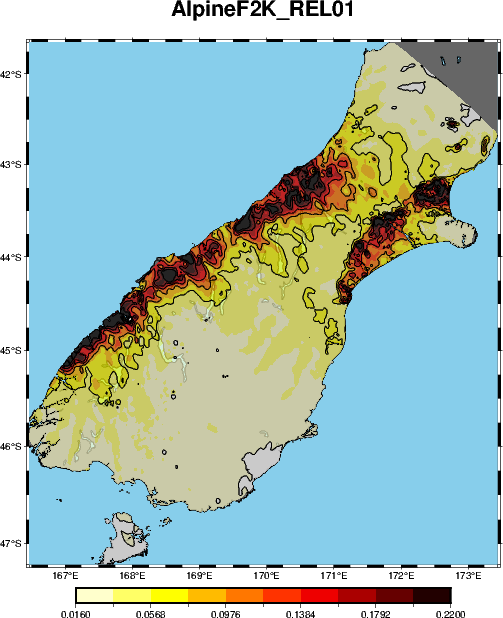

In [46]:
nn_gmm.im_plot(cur_im_data[cur_im_data.realisation == cur_realisation], "pSA_3p0", cur_realisation)

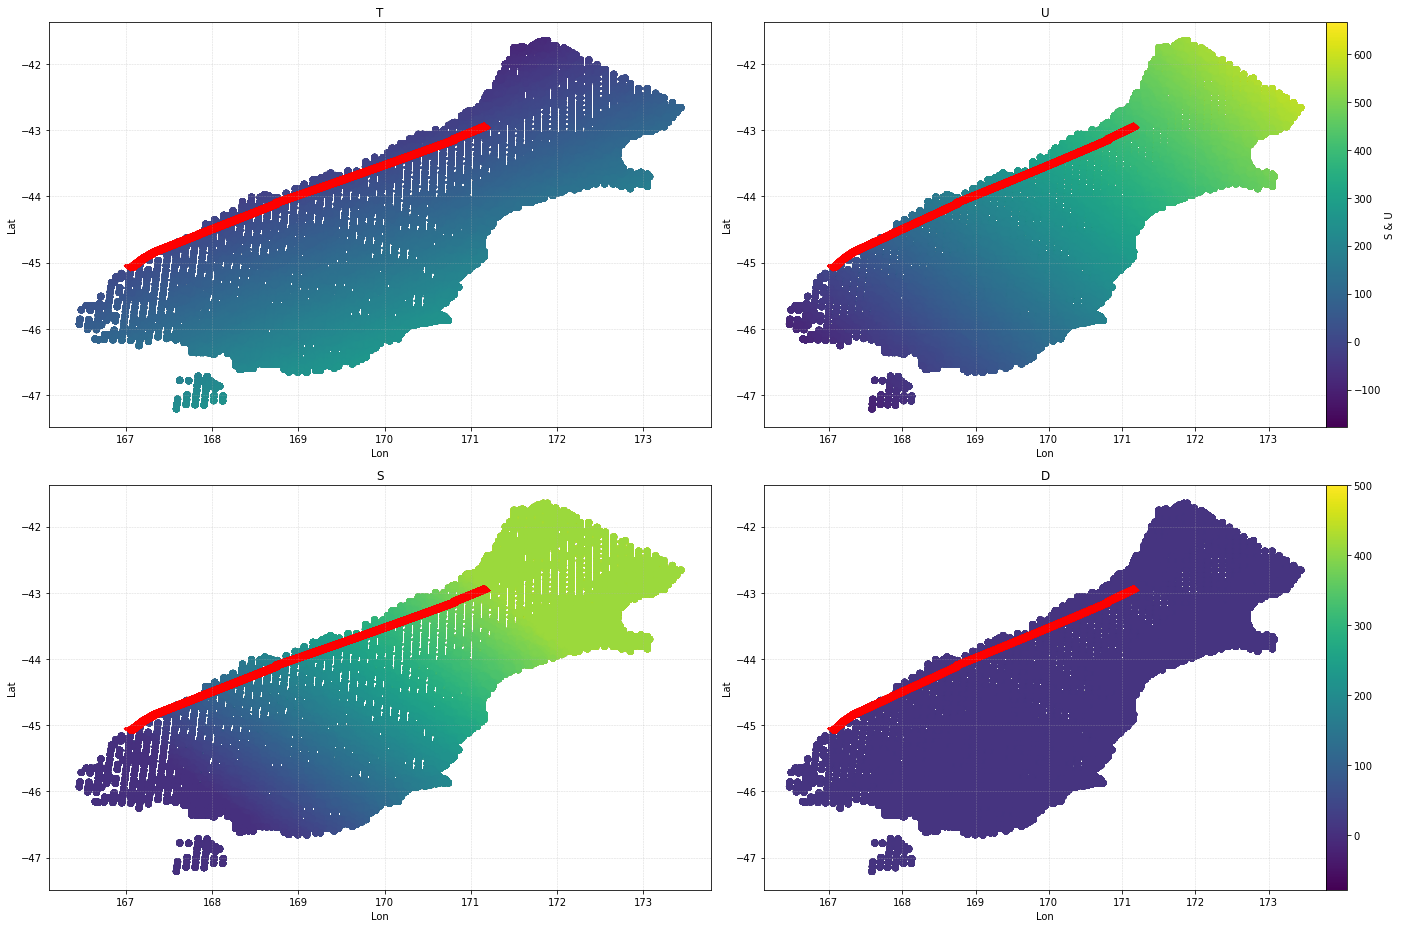

In [16]:
fig = plt.figure(figsize=(20, 13))

# Visualise T and U
vmin, vmax = min(cur_df["T"].min(), cur_df.U.min()), max(cur_df["T"].max(), cur_df.U.max())
ax = fig.add_subplot(2, 2, 1)
ax.scatter(cur_df.lon, cur_df.lat, c=cur_df["T"], vmin=vmin, vmax=vmax)
ax.scatter(cur_srf_points[:, 0], cur_srf_points[:, 1], c="red", s=0.1)
# for cur_plane in cur_srf_header:
#     cur_centre = (cur_plane["centre"][0], cur_plane["centre"][1])
#     shifted = geo.ll_shift(cur_centre[1], cur_centre[0], cur_plane["length"] / 2, cur_plane["strike"])
#     ax.scatter(cur_centre[0], cur_centre[1], marker="x", c="k")
#     ax.arrow(cur_centre[0], cur_centre[1], shifted[1] - cur_centre[0], shifted[0] - cur_centre[1])

ax.set_title(f"T")
ax.set_xlabel(f"Lon")
ax.set_ylabel(f"Lat")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

ax = fig.add_subplot(2, 2, 2)
cb = ax.scatter(cur_df.lon, cur_df.lat, c=cur_df.U, vmin=vmin, vmax=vmax)
ax.scatter(cur_srf_points[:, 0], cur_srf_points[:, 1], c="red", s=0.1)
# for cur_plane in cur_srf_header:
#     cur_centre = (cur_plane["centre"][0], cur_plane["centre"][1])
#     shifted = geo.ll_shift(cur_centre[1], cur_centre[0], cur_plane["length"] / 2, cur_plane["strike"])
#     ax.scatter(cur_centre[0], cur_centre[1], marker="x", c="k")
#     ax.arrow(cur_centre[0], cur_centre[1], shifted[1] - cur_centre[0], shifted[0] - cur_centre[1])

ax.set_title(f"U")
ax.set_xlabel(f"Lon")
ax.set_ylabel(f"Lat")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

cbar = fig.colorbar(cb, ax=ax, pad=0);
cbar.ax.set_ylabel("S & U")

# Visualise S and D
vmin, vmax = min(cur_df.S.min(), cur_df.D.min()), max(cur_df.S.max(), cur_df.D.max())
ax = fig.add_subplot(2, 2, 3)
ax.scatter(cur_df.lon, cur_df.lat, c=cur_df.S, vmin=vmin, vmax=vmax)
ax.scatter(cur_srf_points[:, 0], cur_srf_points[:, 1], c="red", s=0.1)
# for cur_plane in cur_srf_header:
#     cur_centre = (cur_plane["centre"][0], cur_plane["centre"][1])
#     shifted = geo.ll_shift(cur_centre[1], cur_centre[0], cur_plane["length"] / 2, cur_plane["strike"])
#     ax.scatter(cur_centre[0], cur_centre[1], marker="x", c="k")
#     ax.arrow(cur_centre[0], cur_centre[1], shifted[1] - cur_centre[0], shifted[0] - cur_centre[1])

ax.set_title(f"S")
ax.set_xlabel(f"Lon")
ax.set_ylabel(f"Lat")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

ax = fig.add_subplot(2, 2, 4)
cb = ax.scatter(cur_df.lon, cur_df.lat, c=cur_df.D, vmin=vmin, vmax=vmax)
ax.scatter(cur_srf_points[:, 0], cur_srf_points[:, 1], c="red", s=0.1)
# for cur_plane in cur_srf_header:
#     cur_centre = (cur_plane["centre"][0], cur_plane["centre"][1])
#     shifted = geo.ll_shift(cur_centre[1], cur_centre[0], cur_plane["length"] / 2, cur_plane["strike"])
#     ax.scatter(cur_centre[0], cur_centre[1], marker="x", c="k")
#     ax.arrow(cur_centre[0], cur_centre[1], shifted[1] - cur_centre[0], shifted[0] - cur_centre[1])

ax.set_title(f"D")
ax.set_xlabel(f"Lon")
ax.set_ylabel(f"Lat")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.colorbar(cb, ax=ax, pad=0);
fig.tight_layout()